In [96]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.db_connection import get_engine


In [2]:
# Connect to db
engine = get_engine('home_credit')
query = """
    SELECT * FROM application;
"""
df = pd.read_sql(query, engine)
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
# Rows and columns
rows = df.shape[0]
columns = df.shape[1]
print("=" * 40)
print("Shape Of the Dataset")
print(f'Total Rows                     {rows:,.0f}')
print(f'Total Columns                  {columns:,.0f}')

Shape Of the Dataset
Total Rows                     307,511
Total Columns                  122


In [92]:
# Check basic info and statistical measures for a baseline sanity check
print("=" * 40)
print("Basic Info")

df.info()

print(" " * 40)
print("=" * 65)
print("Statistical Measures")
df.describe()

Basic Info
<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(64), int64(42), str(16)
memory usage: 286.2 MB
                                        
Statistical Measures


,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [94]:
# Calculate % missing values per column, sort descending, show top 15
missing_values = df.isnull().sum()

top_15 = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False).head(15)
print("=" * 45)
print("10 columns with highest missing values ratio")
print(" " * 40)
print(top_15)

10 columns with highest missing values ratio
                                        
COMMONAREA_MEDI             69.872297
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
NONLIVINGAPARTMENTS_MEDI    69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_MODE       68.354953
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
FLOORSMIN_AVG               67.848630
FLOORSMIN_MODE              67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_MEDI            66.497784
YEARS_BUILD_MODE            66.497784
dtype: float64


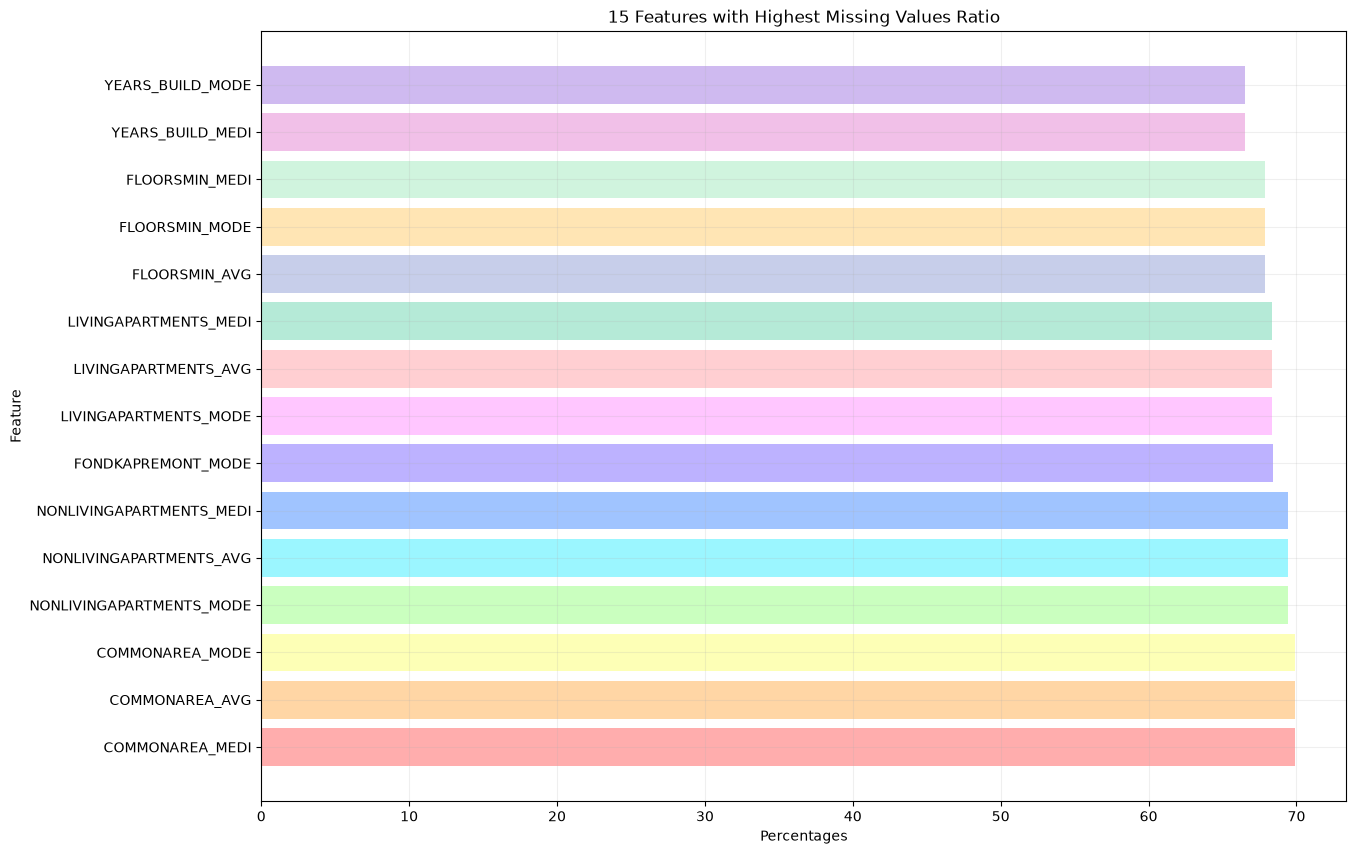

In [29]:
# Plot horizontal bar chart of top 15 columns by % missing values, sorted descending
plt.figure(figsize=(14,10))
plt.barh(
    top_15.index, top_15.values,
    color = [
        '#FFADAD',
        '#FFD6A5',
        '#FDFFB6',
        '#CAFFBF',
        '#9BF6FF',
        '#A0C4FF',
        '#BDB2FF',
        '#FFC6FF',
        '#FFCFD2',
        '#B5EAD7',
        '#C7CEEA',
        '#FFE5B4',
        '#D0F4DE',
        '#F1C0E8',
        '#CFBAF0'
    ]
    )
plt.grid(alpha=0.2)
plt.title("15 Features with Highest Missing Values Ratio")
plt.xlabel("Percentages")
plt.ylabel("Feature")
plt.show()

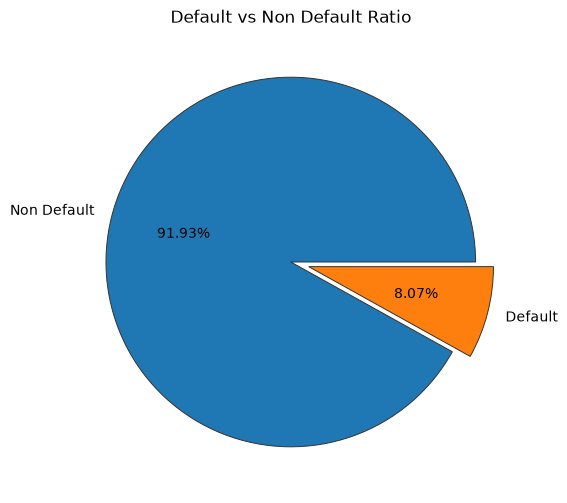

In [50]:
# Target feature ratio
ratio = df['TARGET'].value_counts(normalize=True).rename(index={0:"Non Default", 1:"Default"})

plt.figure(figsize=(6,6))
plt.pie(
    ratio.values, labels=ratio.index,
    autopct='%.2f%%',
    explode=(0.0,0.1),
    wedgeprops= {'edgecolor': '#333', 'linewidth': 0.7}
    )
plt.title("Default vs Non Default Ratio")
plt.show()

Gender


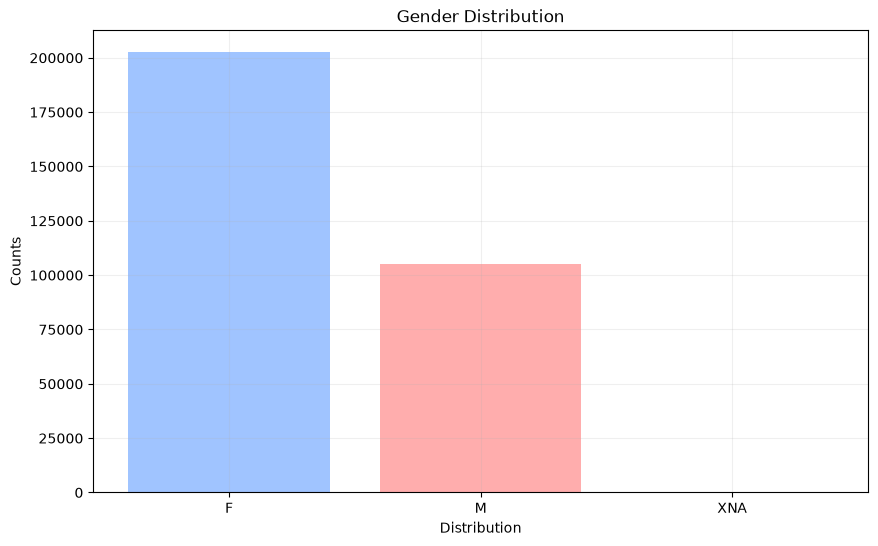

                                                                                                                           
Education


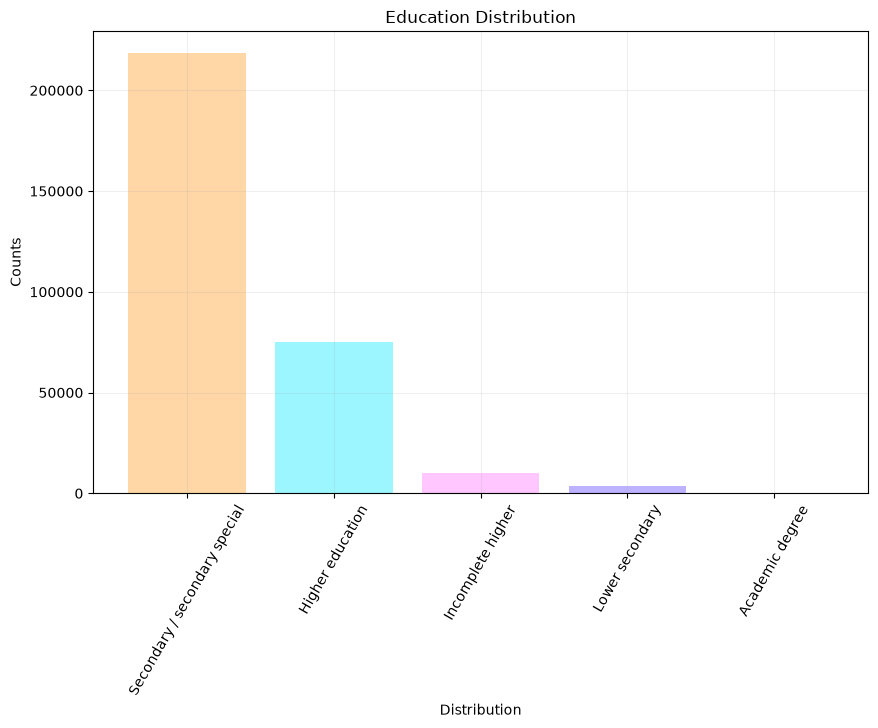

                                                                                                                           
Contract


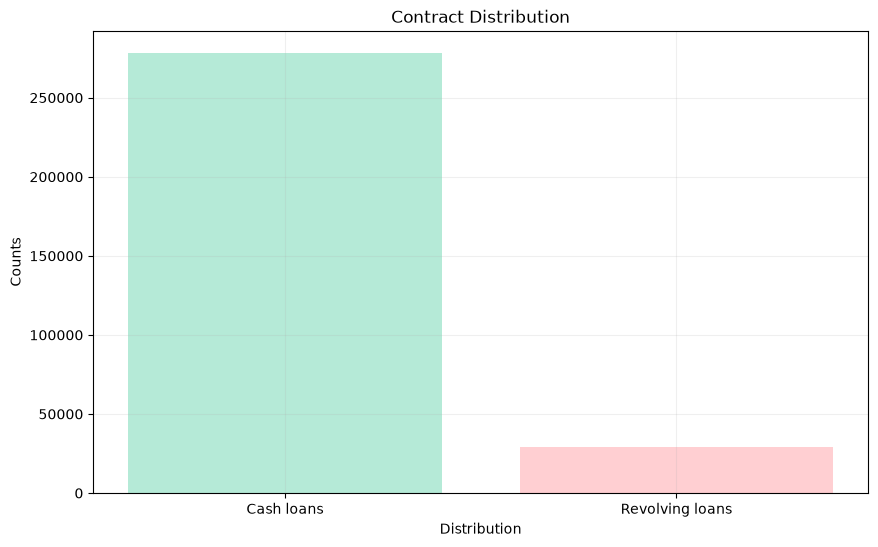

In [118]:
# Plot bar charts for CODE_GENDER, NAME_EDUCATION_TYPE, NAME_CONTRACT_TYPE distributions

# Gender
print("=" * 123)
print("Gender")
gender = df['CODE_GENDER'].value_counts()

plt.figure(figsize=(10,6))
plt.bar(
    gender.index, gender.values,
    color = ['#A0C4FF', '#FFADAD', '#CAFFBF']
    
    )
plt.grid(alpha=0.2)
plt.title("Gender Distribution")
plt.xlabel("Distribution")
plt.ylabel("Counts")
plt.show()


# Education
print(" " * 123)
print("=" * 123)
print("Education")
education = df['NAME_EDUCATION_TYPE'].value_counts()
plt.figure(figsize=(10,6))
plt.bar(
    education.index, education.values,
    color = ['#FFD6A5', '#9BF6FF', '#FFC6FF', '#BDB2FF', '#FDFFB6']
    )
plt.grid(alpha=0.2)
plt.title("Education Distribution")
plt.xlabel("Distribution")
plt.ylabel("Counts")
plt.xticks(rotation=60)
plt.show()

# Contract
print(" " * 123)
print("=" * 123)
print("Contract")
contract = df['NAME_CONTRACT_TYPE'].value_counts()
plt.figure(figsize=(10,6))
plt.bar(
   contract.index, contract.values,
   color = ['#B5EAD7', '#FFCFD2']
    
    )
plt.grid(alpha=0.2)
plt.title("Contract Distribution")
plt.xlabel("Distribution")
plt.ylabel("Counts")
plt.show()


Income


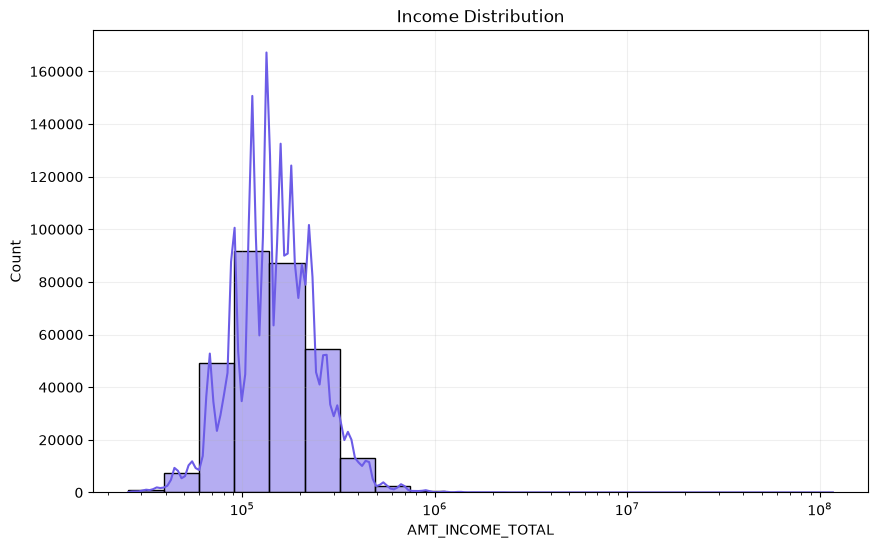

                                                                                                                           
Credit Amount


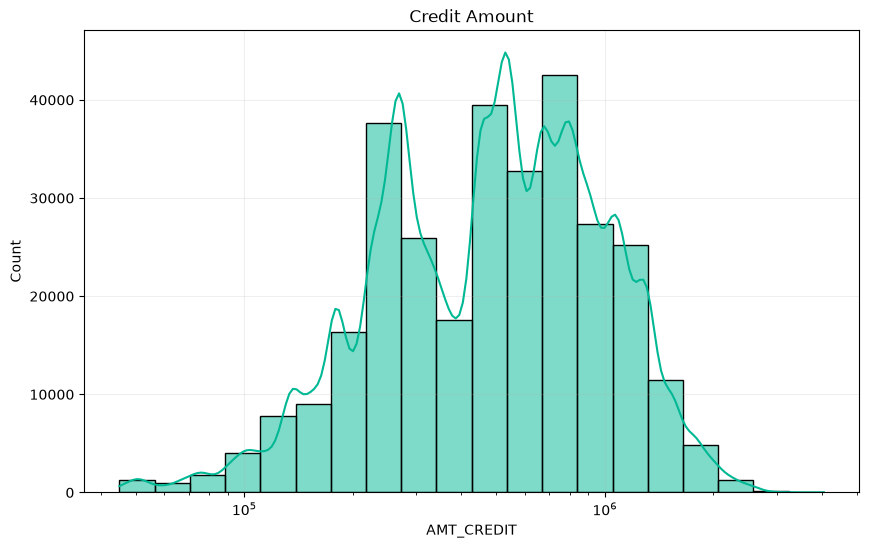

                                                                                                                           
Annuity


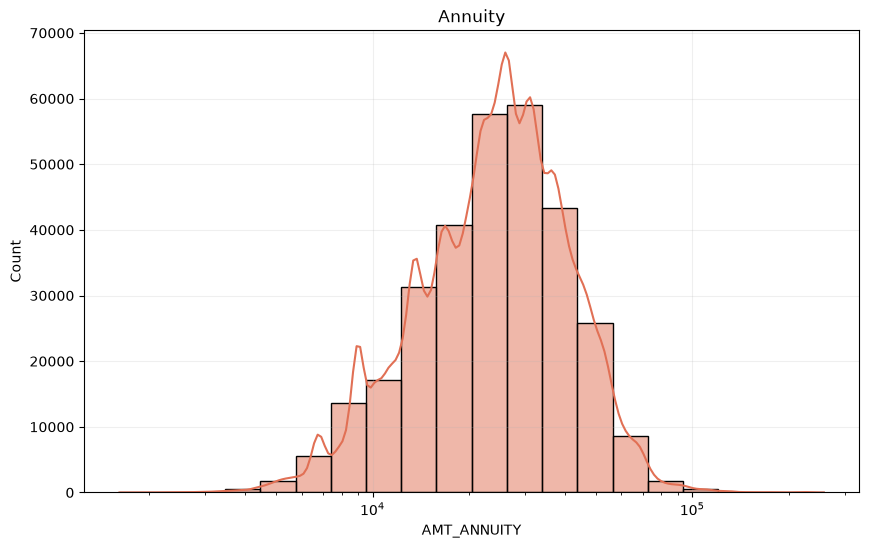

In [129]:
# Plot histograms for AMT_INCOME_TOTAL, AMT_CREDIT, AMT_ANNUITY

# Income
print("=" * 123)
print("Income")
plt.figure(figsize=(10,6))
sns.histplot(
    df['AMT_INCOME_TOTAL'],
    bins = 20,
    log_scale=True,
    kde=True,
    color='#6C5CE7',
    )
plt.title("Income Distribution")
plt.grid(alpha=0.2)
plt.show()


# Credit
print(" " * 123)
print("=" * 123)
print("Credit Amount")

plt.figure(figsize=(10,6))
sns.histplot(
    df['AMT_CREDIT'],
    bins = 20,
    log_scale = True,
    kde = True,
    color= '#00B894'
)
plt.title("Credit Amount")
plt.grid(alpha=0.2)
plt.show()

# Annuity
print(" " * 123)
print("=" * 123)
print("Annuity")

plt.figure(figsize=(10,6))
sns.histplot(
    df['AMT_ANNUITY'],
    bins = 20,
    log_scale= True,
    kde= True,
    color= '#E17055'
)
plt.title("Annuity")
plt.grid(alpha=0.2)
plt.show()
